# Bank Recommendation Analysis (Priority Sector Lending Data)

Data: 27 Indian public-sector banks' Priority Sector Lending (PSL) portfolios and
Minority Community Lending (MCL) share, as of quarter ending 30.06.2014.

**What this data has:** each bank's total PSL book size (Rs Crore) and what share of it
went to minority-community borrowers.

**What this data does NOT have:** interest rates, individual loan products, eligibility
rules, or approval outcomes. So the recommender below is a transparent **heuristic**
(bank scale + community-lending share), not a true predictive/approval model.


## 0. Setup & load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("Upload.csv")
df.columns = ["Bank", "Total_PSL_Cr", "MCL_Cr", "Pct_MCL"]
df["Bank"] = df["Bank"].str.strip()
df = df[df["Bank"].str.lower() != "total"].reset_index(drop=True)
df.head()


,Bank,Total_PSL_Cr,MCL_Cr,Pct_MCL
0,Allahabad Bank,49865.36,7540.53,15.12
1,Andhra Bank,42428.00,5545.01,13.07
2,Bank of Baroda,90075.00,13525.00,15.02
3,Bank of India,84730.00,12909.82,15.24
4,Bank of Maharashtra,32056.45,2747.25,8.57


## 1. Exploratory analysis

In [2]:
df.describe()


,Total_PSL_Cr,MCL_Cr,Pct_MCL
count,27.000000,27.000000,27.000000
mean,57467.140000,8981.312593,15.221481
std,52710.999469,10050.681530,7.150031
min,22.320000,0.530000,2.370000
25%,27632.500000,3872.440000,12.750000
50%,49145.950000,6947.230000,15.020000
75%,66635.400000,8920.695000,15.560000
max,282105.000000,53903.000000,39.490000


/tmp/ipykernel_493/3671280147.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y="Bank", x="Total_PSL_Cr", palette="Blues_r")


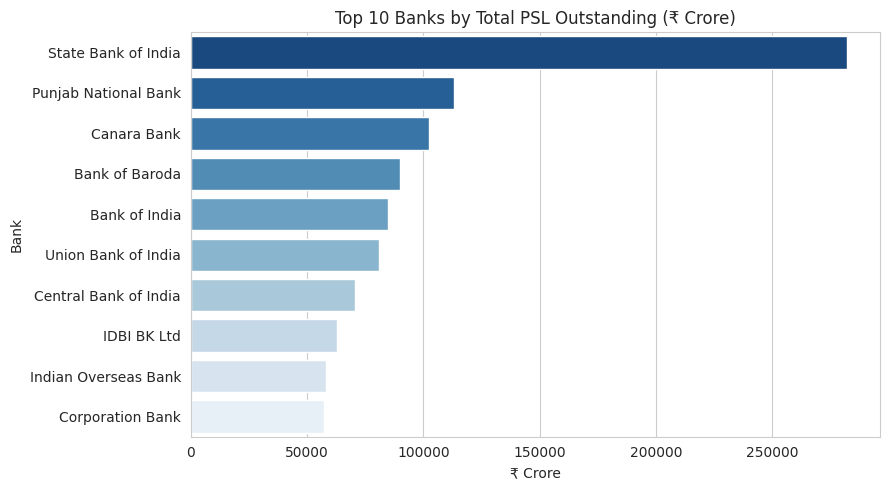

In [3]:
top10 = df.sort_values("Total_PSL_Cr", ascending=False).head(10)
plt.figure(figsize=(9,5))
sns.barplot(data=top10, y="Bank", x="Total_PSL_Cr", palette="Blues_r")
plt.title("Top 10 Banks by Total PSL Outstanding (₹ Crore)")
plt.xlabel("₹ Crore")
plt.tight_layout()
plt.show()


/tmp/ipykernel_493/856643617.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_mcl, y="Bank", x="Pct_MCL", palette="Greens_r")


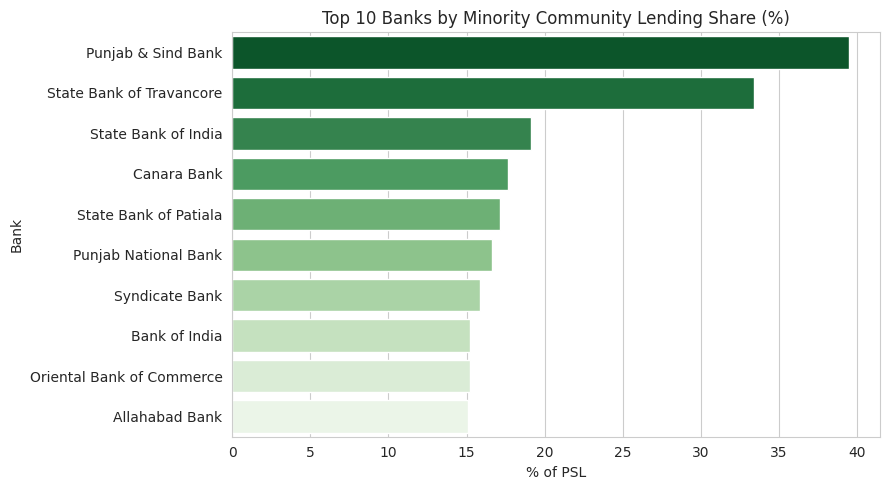

In [4]:
top10_mcl = df.sort_values("Pct_MCL", ascending=False).head(10)
plt.figure(figsize=(9,5))
sns.barplot(data=top10_mcl, y="Bank", x="Pct_MCL", palette="Greens_r")
plt.title("Top 10 Banks by Minority Community Lending Share (%)")
plt.xlabel("% of PSL")
plt.tight_layout()
plt.show()


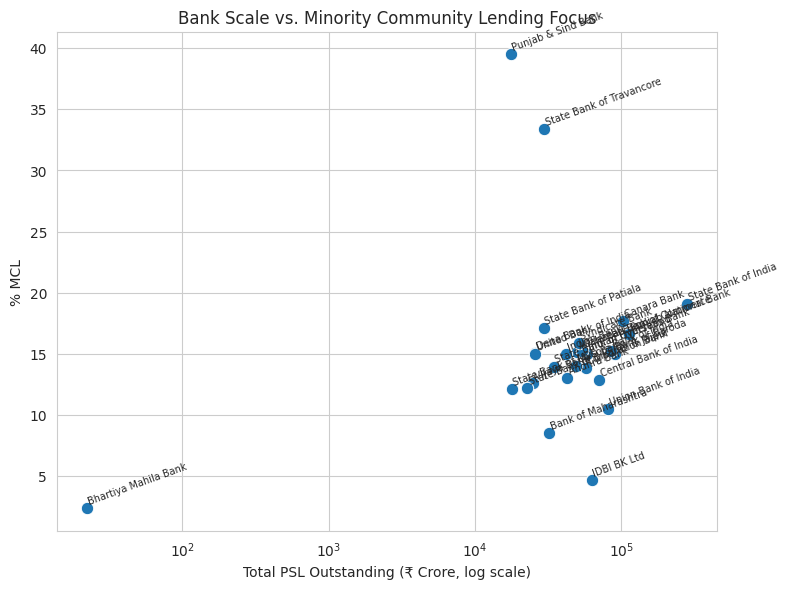

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Total_PSL_Cr", y="Pct_MCL", s=80)
for _, r in df.iterrows():
    plt.text(r["Total_PSL_Cr"], r["Pct_MCL"]+0.3, r["Bank"], fontsize=7, rotation=20)
plt.xscale("log")
plt.xlabel("Total PSL Outstanding (₹ Crore, log scale)")
plt.ylabel("% MCL")
plt.title("Bank Scale vs. Minority Community Lending Focus")
plt.tight_layout()
plt.show()


## 2. Loan-amount-based Bank Recommender

Logic:
- Convert requested amount into a 0-1 position on a realistic log-scale
  (Rs 10,000 personal loan → Rs 1,000 Crore corporate loan).
- Small asks weight **minority-lending share** more (retail/priority-sector-friendly proxy).
- Large asks weight **PSL portfolio size** more (institutional capacity proxy).
- Composite `Suitability_Score` (0-100) ranks the banks for that specific amount.


In [6]:
LOAN_LOG_LOW = np.log10(10_000)
LOAN_LOG_HIGH = np.log10(1_000 * 1e7)

def norm(s):
    return (s - s.min()) / (s.max() - s.min())

df["scale_norm"] = norm(df["Total_PSL_Cr"])
df["mcl_norm"] = norm(df["Pct_MCL"])

def recommend_bank(loan_amount_rs, top_n=5):
    log_amt = np.log10(loan_amount_rs)
    amount_percentile = np.clip((log_amt - LOAN_LOG_LOW) / (LOAN_LOG_HIGH - LOAN_LOG_LOW), 0, 1)
    w_scale = 0.15 + 0.70 * amount_percentile
    w_mcl = 1 - w_scale

    d = df.copy()
    d["Suitability_Score"] = (w_scale * d["scale_norm"] + w_mcl * d["mcl_norm"]) * 100
    return d.sort_values("Suitability_Score", ascending=False).head(top_n)[
        ["Bank", "Total_PSL_Cr", "Pct_MCL", "Suitability_Score"]
    ].round(2).reset_index(drop=True)

# Example: user needs Rs 5,00,000 (5 lakh)
recommend_bank(500_000)


,Bank,Total_PSL_Cr,Pct_MCL,Suitability_Score
0,Punjab & Sind Bank,17593.00,39.49,67.35
1,State Bank of India,282105.00,19.11,64.21
2,State Bank of Travancore,29790.93,33.40,58.16
3,Canara Bank,102595.00,17.68,39.54
4,Punjab National Bank,113034.22,16.61,38.95


In [7]:
# Example: user needs Rs 50,00,00,000 (50 crore)
recommend_bank(50_00_00_000)


,Bank,Total_PSL_Cr,Pct_MCL,Suitability_Score
0,State Bank of India,282105.00,19.11,83.43
1,Punjab National Bank,113034.22,16.61,39.55
2,Canara Bank,102595.00,17.68,37.84
3,Punjab & Sind Bank,17593.00,39.49,34.53
4,State Bank of Travancore,29790.93,33.40,32.60


## 3. Try it yourself

In [8]:
loan_amount = 2_000_000  # <-- change this: amount in plain Rupees
recommend_bank(loan_amount, top_n=5)


,Bank,Total_PSL_Cr,Pct_MCL,Suitability_Score
0,State Bank of India,282105.00,19.11,68.07
1,Punjab & Sind Bank,17593.00,39.49,60.76
2,State Bank of Travancore,29790.93,33.40,53.03
3,Canara Bank,102595.00,17.68,39.20
4,Punjab National Bank,113034.22,16.61,39.07
